In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix)
import seaborn as sns

In [140]:
#Prepare data for input into model
def prepare_data(X): 
    cols_to_drop = ["gid", "visteam", "hometeam", "site", "date", "vruns", "hruns", "wteam", "lteam", "teamID"]
    X = X.drop(cols_to_drop, axis=1)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return X

In [142]:
#Mapping score_diff to classification
def win_lose_mapping(Y):    
    Y = Y.tolist()
    win_lose = []
    for i in range(len(Y)):
        diff = Y[i]
        if diff > 0:
            win_lose.append(1)
        elif diff < 0:
            win_lose.append(0)
        else:
            print("tie")
            win_lose.append(-1) 
    return win_lose

In [144]:
# Model with 1 hidden layer
class SingleHiddenLayerModel(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super(SingleHiddenLayerModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)  # Hidden layer
        self.dropout = nn.Dropout(p=dropout_rate)  # Dropout layer
        self.output = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)  # Apply dropout after activation
        return self.sigmoid(self.output(x))


In [146]:
def train_model(X_train, y_train, X_val, y_val, input_dim, epochs=100, batch_size=32):
    """Train the model for one fold"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Convert to PyTorch tensors
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    model = SingleHiddenLayerModel(input_dim).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).view(-1, 1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).view(-1, 1)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
        
        train_losses.append(train_loss/len(train_loader))
        val_losses.append(val_loss/len(val_loader))
        
    return model, train_losses, val_losses

In [148]:


def run_kfold(X, y, n_splits=5):
    """Run K-Fold cross validation with comprehensive classification metrics"""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Initialize metrics storage
    metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'roc_auc': []
    }
    
    # Create figure for plots
    fig = plt.figure(figsize=(15, 5*n_splits))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\n{'='*40}\nFold {fold+1}/{n_splits}\n{'='*40}")
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Train model
        model, train_loss, val_loss = train_model(X_train, y_train, X_val, y_val, X.shape[1])
        
        # Evaluate
        with torch.no_grad():
            val_probs = model(torch.FloatTensor(X_val).to(next(model.parameters()).device))
            val_probs = val_probs.cpu().numpy()
            val_preds = (val_probs > 0.5).astype(int)
            
            # Calculate metrics
            metrics['accuracy'].append(accuracy_score(y_val, val_preds))
            metrics['precision'].append(precision_score(y_val, val_preds))
            metrics['recall'].append(recall_score(y_val, val_preds))
            metrics['f1'].append(f1_score(y_val, val_preds))
            metrics['roc_auc'].append(roc_auc_score(y_val, val_probs))
            
            # Confusion matrix
            cm = confusion_matrix(y_val, val_preds)
            
        # Plotting
        ax1 = plt.subplot(n_splits, 2, 2*fold+1)
        ax1.plot(train_loss, '--', label='Training Loss')
        ax1.plot(val_loss, '-', label='Validation Loss')
        ax1.set_title(f'Fold {fold+1} - Loss Curves')
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('BCE Loss')
        ax1.legend()
        ax1.grid(True)
        
        ax2 = plt.subplot(n_splits, 2, 2*fold+2)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                   xticklabels=['Predicted 0', 'Predicted 1'],
                   yticklabels=['Actual 0', 'Actual 1'])
        ax2.set_title(f'Fold {fold+1} - Confusion Matrix')
        
        # Print metrics for current fold
        print(f"Accuracy: {metrics['accuracy'][-1]:.4f}")
        print(f"Precision: {metrics['precision'][-1]:.4f}")
        print(f"Recall: {metrics['recall'][-1]:.4f}")
        print(f"F1-Score: {metrics['f1'][-1]:.4f}")
        print(f"ROC-AUC: {metrics['roc_auc'][-1]:.4f}")
    
    plt.tight_layout()
    plt.show()
    
    # Print average metrics
    print("\n\n" + "="*50)
    print("Average Metrics Across All Folds:")
    print(f"Accuracy: {np.mean(metrics['accuracy']):.4f} ± {np.std(metrics['accuracy']):.4f}")
    print(f"Precision: {np.mean(metrics['precision']):.4f} ± {np.std(metrics['precision']):.4f}")
    print(f"Recall: {np.mean(metrics['recall']):.4f} ± {np.std(metrics['recall']):.4f}")
    print(f"F1-Score: {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
    print(f"ROC-AUC: {np.mean(metrics['roc_auc']):.4f} ± {np.std(metrics['roc_auc']):.4f}")
    print("="*50)
    
    return metrics

In [150]:
train = pd.read_csv("../CleanData/full_train.csv")
test = pd.read_csv("../CleanData/full_test.csv")

y_train = train["score_diff"]
x_train = prepare_data(train.drop("score_diff",axis=1)) #dtype nmpy array

y_test = test["score_diff"]
x_test = prepare_data(test.drop("score_diff",axis=1)) #dtype nmpy array

In [151]:
y_train = pd.Series(win_lose_mapping(y_train)).values
y_test = pd.Series(win_lose_mapping(y_test)).values


Fold 1/5
Accuracy: 0.6968
Precision: 0.6957
Recall: 0.6879
F1-Score: 0.6918
ROC-AUC: 0.7699

Fold 2/5
Accuracy: 0.6986
Precision: 0.6994
Recall: 0.7016
F1-Score: 0.7005
ROC-AUC: 0.7728

Fold 3/5
Accuracy: 0.6999
Precision: 0.6912
Recall: 0.7184
F1-Score: 0.7045
ROC-AUC: 0.7694

Fold 4/5
Accuracy: 0.6998
Precision: 0.7076
Recall: 0.6860
F1-Score: 0.6966
ROC-AUC: 0.7691

Fold 5/5
Accuracy: 0.6940
Precision: 0.6937
Recall: 0.7009
F1-Score: 0.6973
ROC-AUC: 0.7673


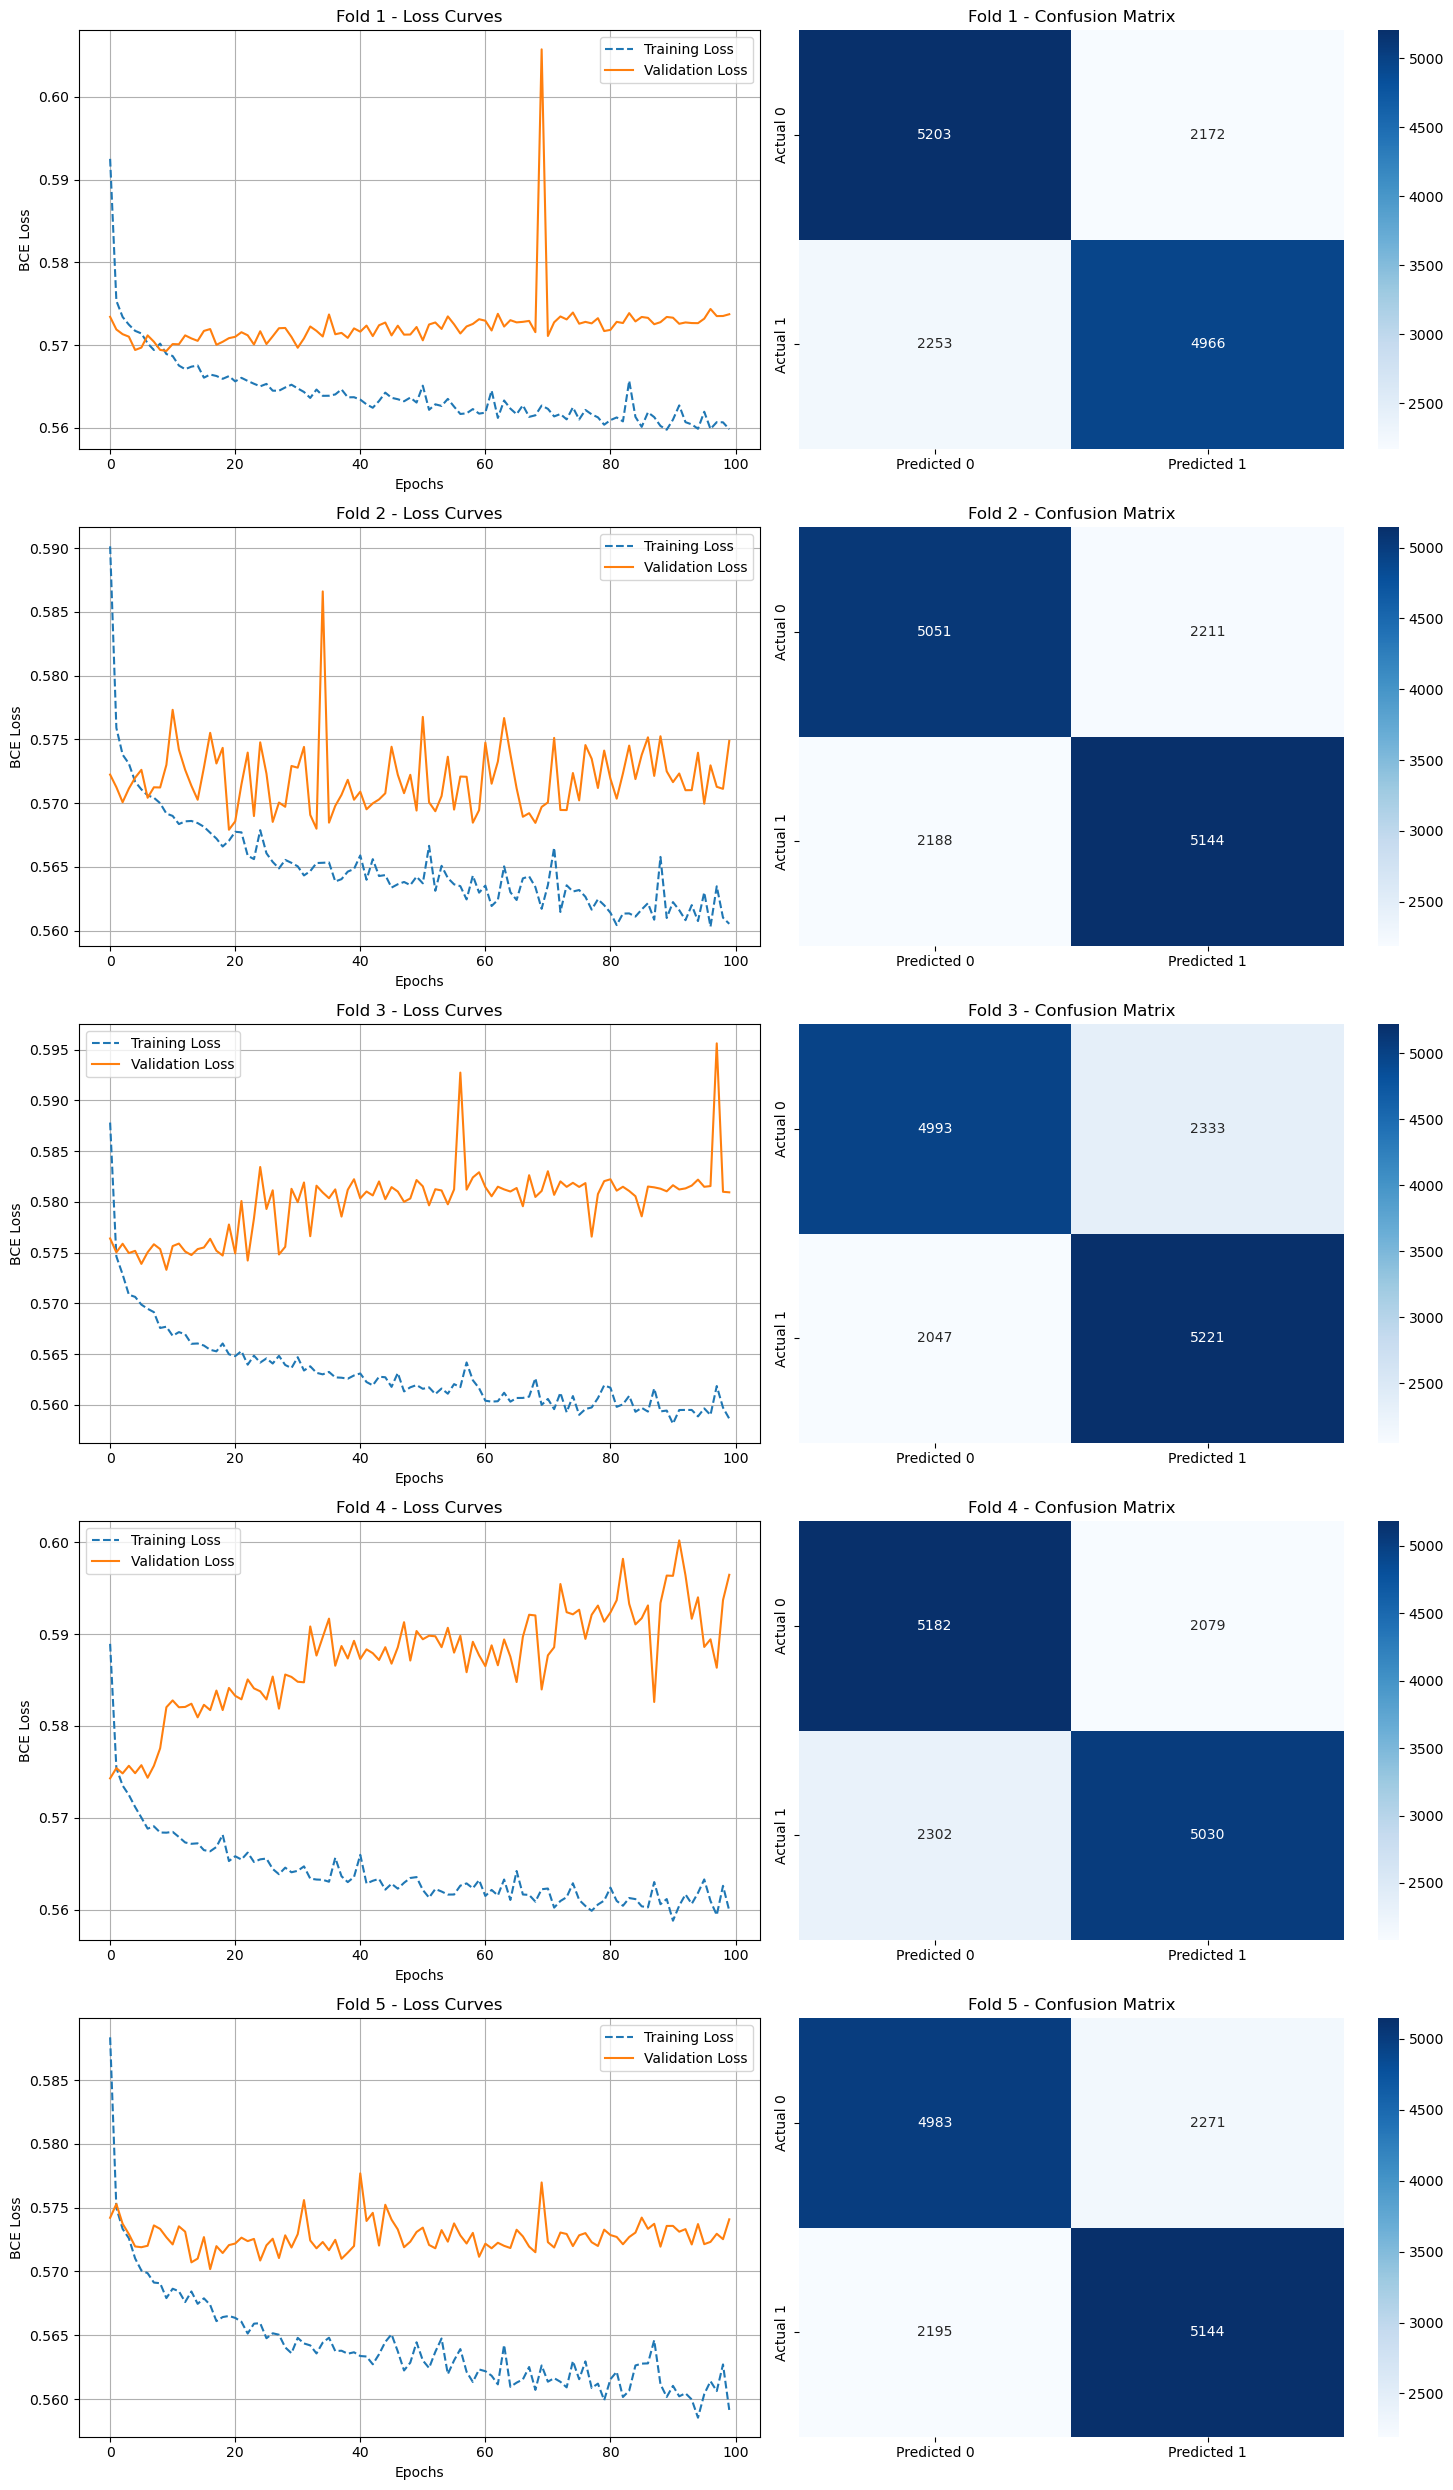



Average Metrics Across All Folds:
Accuracy: 0.6978 ± 0.0022
Precision: 0.6975 ± 0.0057
Recall: 0.6990 ± 0.0116
F1-Score: 0.6981 ± 0.0042
ROC-AUC: 0.7697 ± 0.0018


{'accuracy': [0.6967932026860354,
  0.6985747567493491,
  0.6998766616417705,
  0.6997875693825807,
  0.6939628589049545],
 'precision': [0.6957130848977304,
  0.6993881713120327,
  0.6911570029123643,
  0.7075538050358701,
  0.6937289278489548],
 'recall': [0.687906912314725,
  0.701582105837425,
  0.7183544303797469,
  0.6860338243316967,
  0.7009129309170187],
 'f1': [0.6917879779898307,
  0.7004834207121945,
  0.7044933207394414,
  0.6966276573644484,
  0.6973024264606208],
 'roc_auc': [0.769883569957809,
  0.7727874516780773,
  0.7694103269227099,
  0.7691479706881137,
  0.7672691956621384]}

In [152]:
run_kfold(x_train, y_train)

In [159]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    device = next(model.parameters()).device
    
    # Convert to tensors
    test_data = TensorDataset(torch.FloatTensor(X_test), 
                            torch.FloatTensor(y_test))
    test_loader = DataLoader(test_data, batch_size=32)
    
    # Get predictions and probabilities
    model.eval()
    all_probs = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = outputs.cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_probs.extend(probs.flatten())
            all_preds.extend(preds.flatten())
    
    # Convert to numpy arrays
    y_test = np.array(y_test)
    y_pred = np.array(all_preds)
    y_probs = np.array(all_probs)
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_probs),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Confusion Matrix
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
                ax=axes[0], xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    axes[0].set_title('Confusion Matrix')
    
    # 2. ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_probs, ax=axes[1])
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title('ROC Curve')
    
    plt.tight_layout()
    plt.show()
    
    # Print metrics
    print("\n" + "="*50)
    print("Final Test Evaluation Metrics:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-Score: {metrics['f1']:.4f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print("="*50 + "\n")
    
    return metrics

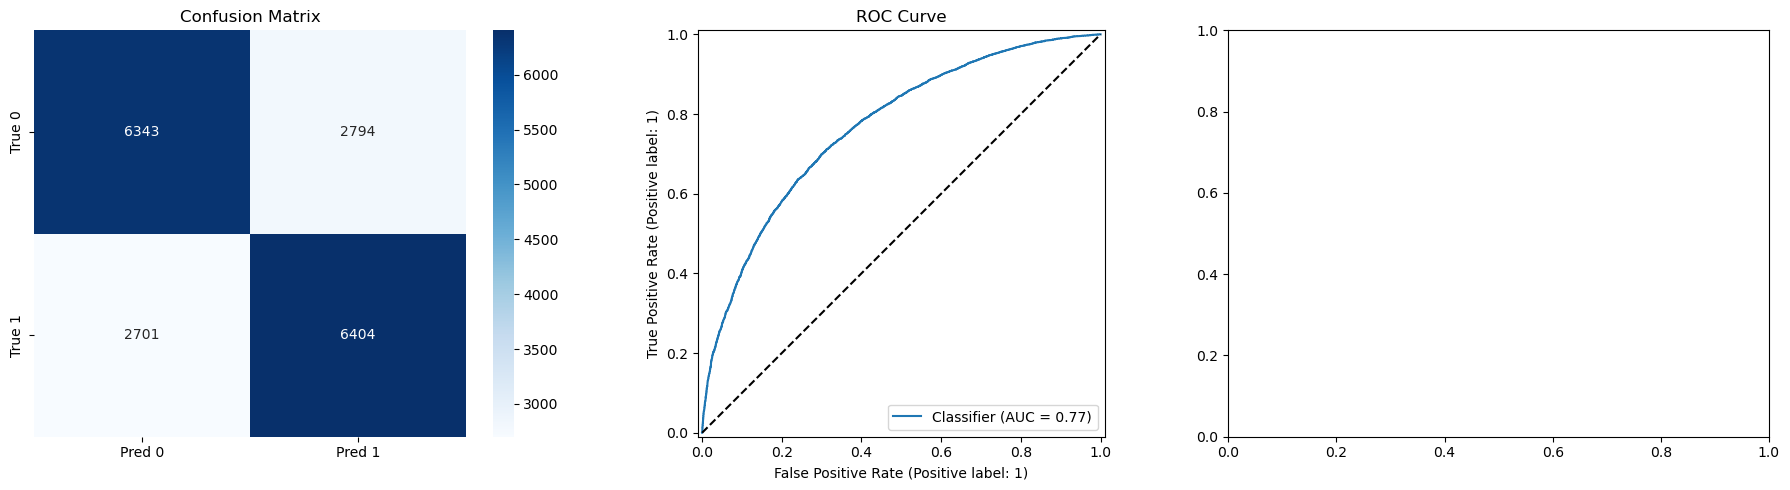


Final Test Evaluation Metrics:
Accuracy: 0.6988
Precision: 0.6962
Recall: 0.7033
F1-Score: 0.6998
ROC-AUC: 0.7677



In [161]:
model= train_model(x_train, y_train, x_test, y_test, input_dim=x_train.shape[1])
test_metrics = evaluate_model(model[0], x_train, y_train, x_test, y_test)

In [162]:
"done"

'done'